# Week 1: Data Wrangling and Initial Exploration
## Theoretical Concepts
Welcome to the first week of our project! This week is all about getting our hands dirty with the data. Before we can do any fancy analysis or build models, we need to understand our data's structure, identify any potential issues, and clean it up. This process is often called Data Wrangling! Most of this is the same as what we have been doing in class.

## Sample Python Code for Week 1
Here is a Python script to guide you through this week's tasks but feel free to use any syntax or packages you want! This is just to help get you started.



Fictitious Wind Turbine DataFrame created successfully!

--- Practice Data: First 5 Rows ---
  turbine_id location  install_year  blade_length_m  power_output_kwh  \
0      T-101  Coastal        2015.0            85.5            4000.0   
1      T-102  Hilltop        2018.0            92.0            4800.0   
2      T-103   Valley           NaN            85.5            3200.0   
3      T-104  Coastal        2015.0            85.5            4200.0   
4      T-105  Hilltop        2019.0            95.0            5100.0   

  maintenance_status  
0        Operational  
1        Operational  
2  Needs Maintenance  
3        Operational  
4        Operational  

--- Practice Data: Info and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   turbine_id          10 non-null     object 
 1   location            9 non-null   

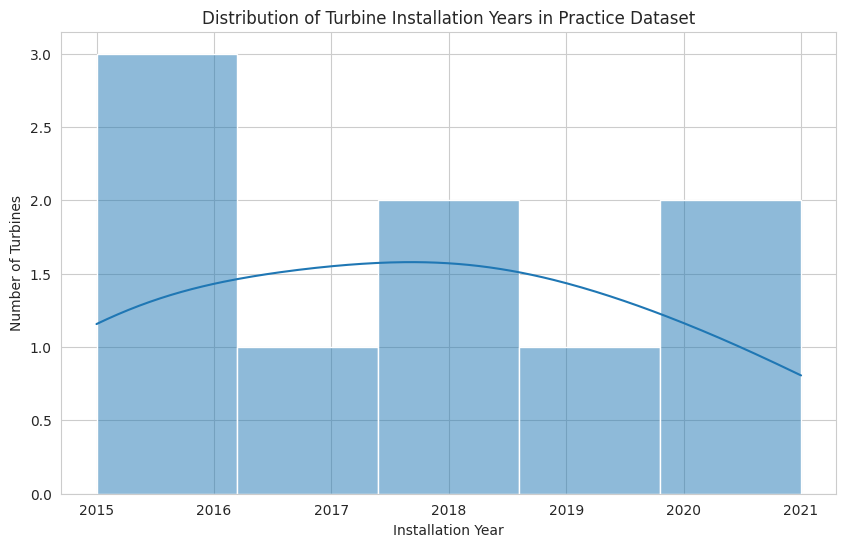

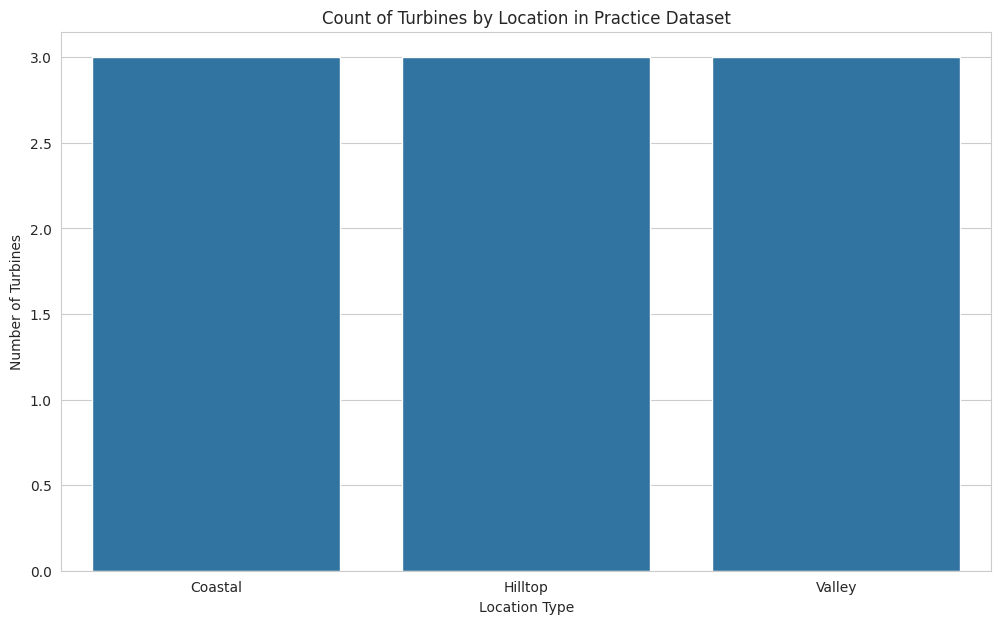

In [1]:
# Import necessary libraries. 'pandas' is for data manipulation,
# 'numpy' is for numerical operations (we'll use it to create missing values),
# and 'matplotlib.pyplot' and 'seaborn' are for data visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Generate Fictitious Data for Practice ---
# We will create a sample DataFrame about wind turbine performance.
# This allows you to practice the concepts without needing the project's CSV files yet.
data = {
    'turbine_id': ['T-101', 'T-102', 'T-103', 'T-104', 'T-105', 'T-106', 'T-107', 'T-108', 'T-109', 'T-110'],
    'location': ['Coastal', 'Hilltop', 'Valley', 'Coastal', 'Hilltop', 'Valley', 'Coastal', 'Hilltop', np.nan, 'Valley'],
    'install_year': [2015, 2018, np.nan, 2015, 2019, 2020, 2016, 2018, 2021, 2017],
    'blade_length_m': [85.5, 92.0, 85.5, 85.5, 95.0, 98.2, 88.0, 92.0, 95.0, 82.0],
    'power_output_kwh': [4000, 4800, 3200, 4200, 5100, 3500, np.nan, 4900, 5200, 3100],
    'maintenance_status': ['Operational', 'Operational', 'Needs Maintenance', 'Operational', 'Operational', 'Needs Maintenance', 'Offline', 'Operational', 'Operational', 'Operational']
}

practice_df = pd.DataFrame(data)

print("Fictitious Wind Turbine DataFrame created successfully!")


# --- 2. Inspect the Data ---
print("\n--- Practice Data: First 5 Rows ---")
print(practice_df.head()) # .head() shows the first 5 rows by default.

print("\n--- Practice Data: Info and Data Types ---")
print(practice_df.info()) # .info() gives a summary of the DataFrame, including data types and non-null counts.

# --- 3. Check for Missing Values ---
print("\n--- Practice Data: Missing Value Counts ---")
# .isnull() creates a boolean DataFrame (True for missing, False for not).
# .sum() then counts the number of 'True' values in each column.
print(practice_df.isnull().sum())

# --- 4. Calculate Summary Statistics ---
# .describe() calculates summary statistics for all numerical columns.
print("\n--- Practice Data: Summary Statistics for Numerical Columns ---")
print(practice_df.describe())

# --- 5. Create Initial Visualizations ---
# Let's visualize the distribution of two key columns.

# Set a nice style for the plots
sns.set_style("whitegrid")

# a) Histogram of Turbine Installation Year ('install_year')
plt.figure(figsize=(10, 6)) # Create a figure to draw on, with a specific size.
sns.histplot(practice_df['install_year'].dropna(), bins=5, kde=True) # dropna() removes missing values for this plot
plt.title('Distribution of Turbine Installation Years in Practice Dataset')
plt.xlabel('Installation Year')
plt.ylabel('Number of Turbines')
plt.show() # This displays the plot.

# b) Bar Chart of Turbine Locations ('location')
plt.figure(figsize=(12, 7))
# .value_counts() gets the counts of each unique value in the column.
# .index gets the names (e.g., "Coastal"), and .values gets the counts.
sns.barplot(x=practice_df['location'].value_counts().index, y=practice_df['location'].value_counts().values)
plt.title('Count of Turbines by Location in Practice Dataset')
plt.xlabel('Location Type')
plt.ylabel('Number of Turbines')
plt.show()



#Week 2: Exploratory Data Analysis (EDA)
##Theoretical Concepts
Now that we've cleaned our data, we can move on to the fun part: Exploratory Data Analysis (EDA). The goal of EDA is to "get to know" the data. We want to uncover patterns, spot anomalies, test hypotheses, and check assumptions with the help of summary statistics and graphical representations.

1. Asking Questions
EDA is an iterative process of asking and answering questions. For our wind turbine dataset, we might ask: "Does the location of a turbine affect its power output?" or "Is there a relationship between blade length and power output?"

2. Visualizing Relationships
This week, we move beyond single-variable plots (like histograms) to multi-variable plots that show relationships between two or more variables.

  * Scatter Plots: These are the classic way to visualize the relationship between two numerical variables. Each point on the plot represents a single data point (e.g., a single turbine). For example, you could plot blade_length_m on the x-axis and power_output_kwh on the y-axis to see if longer blades tend to generate more power.

  * Crosstabulation (Contingency Table): A powerful tool to see the frequency distribution of two categorical variables. It creates a table that shows how many times each combination of categories appears. For example, the rows could be location and the columns could be maintenance_status.

  * Box Plots: Perfect for visualizing the distribution of a numerical variable across several categories. For instance, you can use a box plot to see if the distribution of power_output_kwh is different for turbines in "Coastal" vs. "Hilltop" locations. A box plot shows the median, quartiles, and potential outliers, making it great for comparisons.

  * Heatmaps: A heatmap is a great way to visualize a crosstabulation. It uses color to represent the values in the table, making it easy to spot patterns at a glance. Darker colors might indicate higher counts, for example.

## Sample Python Code for Week 2
This script continues with the wind turbine practice_df we created in Week 1.

/tmp/ipython-input-2701472543.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  practice_df['install_year'].fillna(practice_df['install_year'].median(), inplace=True)
/tmp/ipython-input-2701472543.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

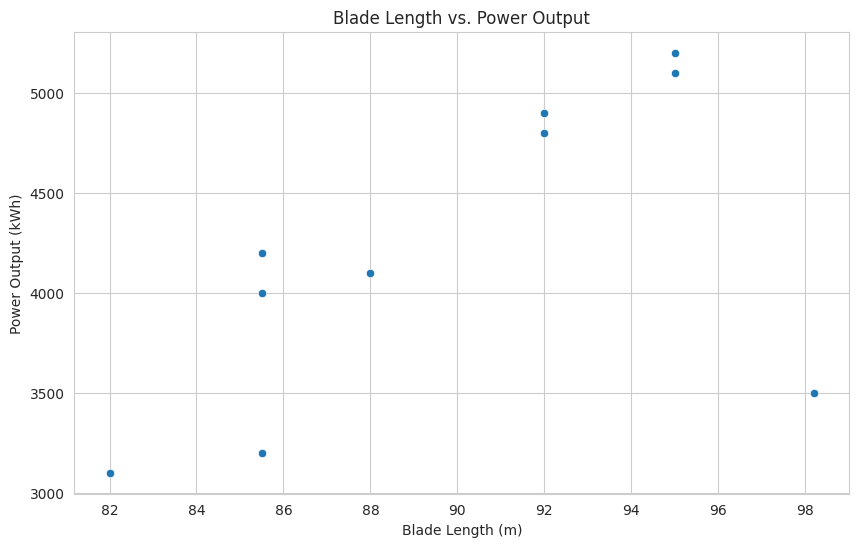


--- Crosstabulation: Location vs. Maintenance Status ---
maintenance_status  Needs Maintenance  Offline  Operational
location                                                   
Coastal                             0        1            3
Hilltop                             0        0            3
Valley                              2        0            1


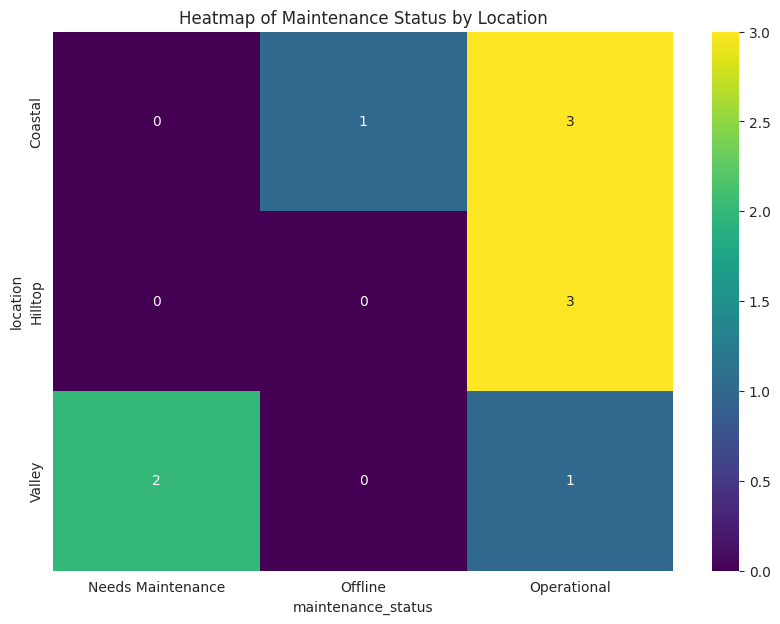

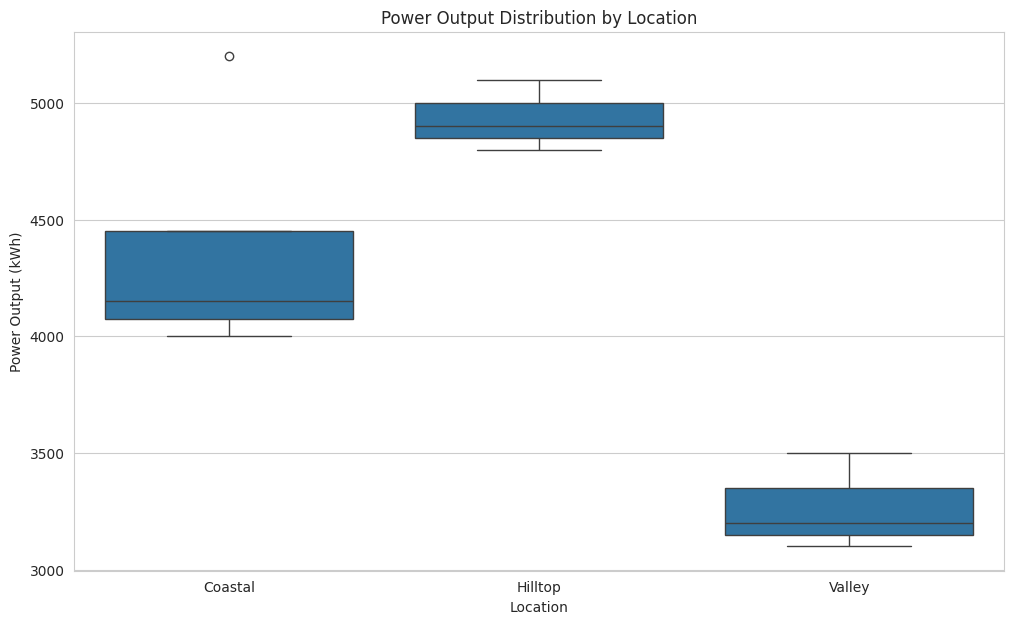

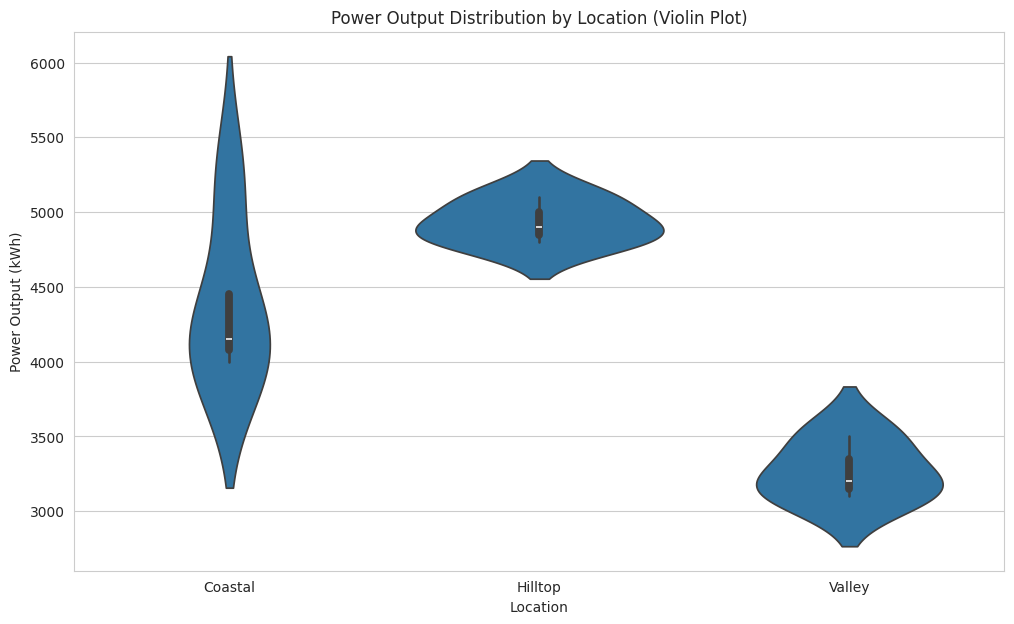

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Re-create the Fictitious Data for Practice ---
# We'll use the same wind turbine dataset from Week 1.
data = {
    'turbine_id': ['T-101', 'T-102', 'T-103', 'T-104', 'T-105', 'T-106', 'T-107', 'T-108', 'T-109', 'T-110'],
    'location': ['Coastal', 'Hilltop', 'Valley', 'Coastal', 'Hilltop', 'Valley', 'Coastal', 'Hilltop', 'Coastal', 'Valley'],
    'install_year': [2015, 2018, 2019, 2015, 2019, 2020, 2016, 2018, 2021, 2017],
    'blade_length_m': [85.5, 92.0, 85.5, 85.5, 95.0, 98.2, 88.0, 92.0, 95.0, 82.0],
    'power_output_kwh': [4000, 4800, 3200, 4200, 5100, 3500, 4100, 4900, 5200, 3100],
    'maintenance_status': ['Operational', 'Operational', 'Needs Maintenance', 'Operational', 'Operational', 'Needs Maintenance', 'Offline', 'Operational', 'Operational', 'Operational']
}
practice_df = pd.DataFrame(data)

# For this week, let's fill the missing values for simplicity in plotting.
# We'll fill numerical NaNs with the median and categorical NaNs with the mode.
practice_df['install_year'].fillna(practice_df['install_year'].median(), inplace=True)
practice_df['power_output_kwh'].fillna(practice_df['power_output_kwh'].median(), inplace=True)
practice_df['location'].fillna(practice_df['location'].mode()[0], inplace=True)


# --- 2. Investigate Relationships ---

# a) Relationship between two numerical variables (Scatter Plot)
# Is there a relationship between blade length and power output?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=practice_df, x='blade_length_m', y='power_output_kwh')
plt.title('Blade Length vs. Power Output')
plt.xlabel('Blade Length (m)')
plt.ylabel('Power Output (kWh)')
plt.grid(True)
plt.show()

# b) Relationship between two categorical variables (Crosstabulation and Heatmap)
# How does maintenance status vary by location?
location_maintenance_crosstab = pd.crosstab(practice_df['location'], practice_df['maintenance_status'])
print("\n--- Crosstabulation: Location vs. Maintenance Status ---")
print(location_maintenance_crosstab)

# Now, visualize this crosstab with a heatmap.
plt.figure(figsize=(10, 7))
sns.heatmap(location_maintenance_crosstab, annot=True, fmt='d', cmap='viridis')
plt.title('Heatmap of Maintenance Status by Location')
plt.show()

# c) Relationship between a numerical and a categorical variable (Box Plot)
# Does power output differ by location?
plt.figure(figsize=(12, 7))
sns.boxplot(data=practice_df, x='location', y='power_output_kwh')
plt.title('Power Output Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Power Output (kWh)')
plt.show()

# You can also use a violin plot for a more detailed distribution view.
plt.figure(figsize=(12, 7))
sns.violinplot(data=practice_df, x='location', y='power_output_kwh')
plt.title('Power Output Distribution by Location (Violin Plot)')
plt.xlabel('Location')
plt.ylabel('Power Output (kWh)')
plt.show()



# Weeks 3 & 4: Introduction to Predictive Modeling
## Theoretical Concepts
Welcome to the final phase of our project! We've cleaned our data and explored it to find patterns. Now, we will use those patterns to make predictions. This is the core of Machine Learning (ML).

What is Supervised Machine Learning? The type of ML we'll be doing is called Supervised Learning. The "supervised" part means we have a dataset where we already know the correct outcomes. We will use this labeled data to "train" a model. Our goal is to train a model that can make accurate predictions on new, unseen data where we don't know the outcome. In our practice scenario, we want to predict the maintenance_status of a wind turbine based on its characteristics (like location, install_year, etc.).

Building a model follows a standard process:
  * Feature and Target Selection
    * Target Variable (y): This is the single column we want to predict. In our practice case, it's maintenance_status.

    * Feature Variables (X): These are the columns we will use to make the prediction. Examples: location, install_year, blade_length_m.

  * Preprocessing for Machine Learning
    * Machine learning models are mathematical, so they need all input to be numerical. We can't feed them text like "Coastal". One-Hot Encoding is a common technique to convert categorical data into a numerical format. It creates new columns for each category. For a location column with "Coastal" and "Hilltop", it would create two new columns: location_Coastal and location_Hilltop. A row with "Coastal" would have a 1 in the location_Coastal column and a 0 in the other.

* Train-Test Split: We need to know if our model is actually good at predicting. If we train and test it on the same data, it's like giving a student an exam with the answers attached. They'll get a perfect score, but we won't know if they've truly learned anything.To solve this, we split our data into two parts:

  * Training Set (usually ~80%): The model learns the patterns from this data.

  * Testing Set (usually ~20%): We hold this data back. After the model is trained, we use the testing set to evaluate its performance on unseen data.

*  Choosing and Training a Model: There are many types of ML models. We will start with a simple but powerful one: the Decision Tree. A Decision Tree makes predictions by learning a series of "if/else" questions about the features. Training is the process where the model learns the patterns from the training data. In scikit-learn, this is done with the .fit() method.

    * Evaluation: After training, we make predictions on our testing set and compare them to the actual known outcomes.

    * Accuracy: The simplest metric. It's the percentage of predictions the model got right.

    * Classification Report: A more detailed report that shows how well the model performed for each individual category (e.g., how well it identified "Operational" vs. "Needs Maintenance").

## Sample Python Code for Weeks 3 & 4
This script uses the wind turbine dataset to build a model that predicts maintenance_status.

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
# We now import tools from scikit-learn, the primary ML library in Python
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- 1. Re-create and Prepare the Data ---
data = {
    'turbine_id': ['T-101', 'T-102', 'T-103', 'T-104', 'T-105', 'T-106', 'T-107', 'T-108', 'T-109', 'T-110'],
    'location': ['Coastal', 'Hilltop', 'Valley', 'Coastal', 'Hilltop', 'Valley', 'Coastal', 'Hilltop', 'Coastal', 'Valley'],
    'install_year': [2015, 2018, 2019, 2015, 2019, 2020, 2016, 2018, 2021, 2017],
    'blade_length_m': [85.5, 92.0, 85.5, 85.5, 95.0, 98.2, 88.0, 92.0, 95.0, 82.0],
    'power_output_kwh': [4000, 4800, 3200, 4200, 5100, 3500, 4100, 4900, 5200, 3100],
    'maintenance_status': ['Operational', 'Operational', 'Needs Maintenance', 'Operational', 'Operational', 'Needs Maintenance', 'Offline', 'Operational', 'Operational', 'Operational']
}
practice_df = pd.DataFrame(data)
# Let's focus on predicting 'Operational' vs. 'Needs Maintenance'
# We will filter out the 'Offline' status for this simple example
practice_df = practice_df[practice_df['maintenance_status'] != 'Offline'].copy()


# --- 2. Feature and Target Selection ---
# Define our target variable (what we want to predict)
target = 'maintenance_status'
y = practice_df[target]

# Define our features (the information we'll use to make the prediction)
# We'll exclude the turbine_id as it's just an identifier
features = ['location', 'install_year', 'blade_length_m', 'power_output_kwh']
X = practice_df[features]


# --- 3. Preprocessing for Machine Learning (One-Hot Encoding) ---
# Models need numerical input. We'll convert the 'location' column.
# pd.get_dummies() automatically finds categorical columns and converts them.
X_encoded = pd.get_dummies(X, columns=['location'], drop_first=True)

print("--- Original Features ---")
print(X.head())
print("\n--- One-Hot Encoded Features ---")
print(X_encoded.head()) # Note the new 'location_Hilltop' and 'location_Valley' columns


# --- 4. Train-Test Split ---
# We split our data: 80% for training, 20% for testing.
# random_state ensures that the split is the same every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


# --- 5. Choose and Train the Model ---
# We'll use a Decision Tree Classifier.
# We create an "instance" of the model.
model = DecisionTreeClassifier(random_state=42)

# Now we train the model on our training data.
model.fit(X_train, y_train)

print("\nModel training complete!")


# --- 6. Make Predictions and Evaluate ---
# Now, let's see how our trained model performs on the unseen test data.
y_pred = model.predict(X_test)

# Compare the model's predictions (y_pred) with the actual answers (y_test).
# a) Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")

# b) Classification Report
# This gives a more detailed breakdown of performance.
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, zero_division=0))



--- Original Features ---
  location  install_year  blade_length_m  power_output_kwh
0  Coastal          2015            85.5              4000
1  Hilltop          2018            92.0              4800
2   Valley          2019            85.5              3200
3  Coastal          2015            85.5              4200
4  Hilltop          2019            95.0              5100

--- One-Hot Encoded Features ---
   install_year  blade_length_m  power_output_kwh  location_Hilltop  \
0          2015            85.5              4000             False   
1          2018            92.0              4800              True   
2          2019            85.5              3200             False   
3          2015            85.5              4200             False   
4          2019            95.0              5100              True   

   location_Valley  
0            False  
1            False  
2             True  
3            False  
4            False  

Training set size: 7 samples
Tes

## Resources

Here are some resources that can help you with this project:

*   **Seaborn Documentation:** [https://seaborn.pydata.org/api.html](https://seaborn.pydata.org/api.html) - The official documentation for the Seaborn library.
*   **Scikit-learn Documentation:** [https://scikit-learn.org/stable/documentation.html](https://scikit-learn.org/stable/documentation.html) - The official documentation for the scikit-learn library.
*   **Introduction to Data Wrangling:** [https://towardsdatascience.com/data-wrangling-with-python-and-pandas-f8c459718e98](https://towardsdatascience.com/data-wrangling-with-python-and-pandas-f8c459718e98) - A tutorial on data wrangling with pandas.
*   **Exploratory Data Analysis (EDA) Guide:** [https://towardsdatascience.com/exploratory-data-analysis-eda-a-step-by-step-guide-to-understand-your-data-for-machine-learning-a98c530743e3](https://towardsdatascience.com/exploratory-data-analysis-eda-a-step-by-step-guide-to-understand-your-data-for-machine-learning-a98c530743e3) - A guide to performing EDA.
*   **Introduction to Machine Learning:** [https://developers.google.com/machine-learning/crash-course](https://developers.google.com/machine-learning/crash-course) - Google's Machine Learning Crash Course.
*   **Decision Tree Classifier Tutorial:** [https://scikit-learn.org/stable/modules/tree.html](https://scikit-learn.org/stable/modules/tree.html) - Documentation and examples for the Decision Tree Classifier in scikit-learn.